# Multiclass Dataset Statistics

This notebook provides comprehensive statistics and visualizations for the multiclass counting benchmark dataset.

In [21]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path

# Set plot style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Dataset Files

In [22]:
# Load all JSON files
with open('annotations.json', 'r') as f:
    annotations = json.load(f)

with open('class_mapping.json', 'r') as f:
    class_mapping = json.load(f)

with open('multiclass_gt_counts.json', 'r') as f:
    gt_counts = json.load(f)

with open('multiclass_class_counts_per_image.json', 'r') as f:
    class_counts_per_image = json.load(f)

with open('multiclass_split_images.json', 'r') as f:
    split_images = json.load(f)

with open('multiclass_split_classes.json', 'r') as f:
    split_classes = json.load(f)

print("✓ All dataset files loaded successfully")

✓ All dataset files loaded successfully


## Basic Dataset Statistics

In [23]:
# Total images
total_images = len(gt_counts)

# Total classes
total_classes = len(class_mapping)
class_names = list(class_mapping.values())

# Total objects across all images
total_objects = sum(gt_counts.values())

# Average count per image
avg_count_per_image = total_objects / total_images

print("="*60)
print("MULTICLASS COUNTING DATASET STATISTICS")
print("="*60)
print(f"\nTotal Images: {total_images}")
print(f"Total Classes: {total_classes}")
print(f"Total Object Instances: {total_objects:,}")
print(f"\nAverage Objects per Image: {avg_count_per_image:.2f}")
print(f"Min Objects per Image: {min(gt_counts.values())}")
print(f"Max Objects per Image: {max(gt_counts.values())}")
print(f"Median Objects per Image: {np.median(list(gt_counts.values())):.2f}")
print("="*60)

MULTICLASS COUNTING DATASET STATISTICS

Total Images: 200
Total Classes: 45
Total Object Instances: 11,576

Average Objects per Image: 57.88
Min Objects per Image: 3
Max Objects per Image: 955
Median Objects per Image: 26.50


## Classes per Image Statistics

In [24]:
# Calculate number of classes per image
classes_per_image = []
for img_name, class_counts in class_counts_per_image.items():
    num_classes = sum(1 for count in class_counts.values() if count > 0)
    classes_per_image.append(num_classes)

avg_classes_per_image = np.mean(classes_per_image)
median_classes_per_image = np.median(classes_per_image)
min_classes = min(classes_per_image)
max_classes = max(classes_per_image)

print("Classes per Image Statistics:")
print(f"  Average: {avg_classes_per_image:.2f}")
print(f"  Median: {median_classes_per_image:.0f}")
print(f"  Min: {min_classes}")
print(f"  Max: {max_classes}")
print(f"  Std Dev: {np.std(classes_per_image):.2f}")

# Distribution of classes per image
classes_distribution = Counter(classes_per_image)
print(f"\nDistribution of number of classes per image:")
for num_classes in sorted(classes_distribution.keys()):
    count = classes_distribution[num_classes]
    percentage = (count / len(classes_per_image)) * 100
    print(f"  {num_classes} classes: {count} images ({percentage:.1f}%)")

Classes per Image Statistics:
  Average: 2.55
  Median: 2
  Min: 2
  Max: 7
  Std Dev: 0.87

Distribution of number of classes per image:
  2 classes: 126 images (63.0%)
  3 classes: 49 images (24.5%)
  4 classes: 17 images (8.5%)
  5 classes: 6 images (3.0%)
  6 classes: 1 images (0.5%)
  7 classes: 1 images (0.5%)


## Per-Class Statistics

In [25]:
# Calculate statistics per class
class_stats = defaultdict(lambda: {'total_instances': 0, 'num_images': 0, 'counts': []})

for img_name, class_counts in class_counts_per_image.items():
    for class_name, count in class_counts.items():
        if count > 0:
            class_stats[class_name]['total_instances'] += count
            class_stats[class_name]['num_images'] += 1
            class_stats[class_name]['counts'].append(count)

# Create a DataFrame for easier analysis
class_stats_list = []
for class_name in class_names:
    stats = class_stats[class_name]
    if stats['num_images'] > 0:
        avg_count = stats['total_instances'] / stats['num_images']
        class_stats_list.append({
            'Class': class_name,
            'Total Instances': stats['total_instances'],
            'Num Images': stats['num_images'],
            'Avg per Image': avg_count,
            'Min': min(stats['counts']),
            'Max': max(stats['counts']),
            'Std Dev': np.std(stats['counts'])
        })
    else:
        class_stats_list.append({
            'Class': class_name,
            'Total Instances': 0,
            'Num Images': 0,
            'Avg per Image': 0,
            'Min': 0,
            'Max': 0,
            'Std Dev': 0
        })

df_class_stats = pd.DataFrame(class_stats_list)
df_class_stats = df_class_stats.sort_values('Total Instances', ascending=False)

print("\nPer-Class Statistics (sorted by total instances):")
print(df_class_stats.to_string(index=False))

# Average objects per class
avg_instances_per_class = df_class_stats['Total Instances'].mean()
print(f"\nAverage instances per class: {avg_instances_per_class:.2f}")


Per-Class Statistics (sorted by total instances):
          Class  Total Instances  Num Images  Avg per Image  Min  Max    Std Dev
         people             3756          60      62.600000    1  679 114.898390
           cars              959          40      23.975000    1  113  25.404220
beach umbrellas              675          10      67.500000    4  239  71.957279
    blueberries              627          14      44.785714    3  128  39.706384
       cherries              573           6      95.500000    2  394 139.685062
     motorbikes              472          25      18.880000    1   64  19.920482
        windows              353          11      32.090909    9   72  17.748007
        guitars              323          16      20.187500    1  121  28.851384
         chairs              314          15      20.933333    1   61  17.755625
   red currants              301           6      50.166667   21  103  28.649704
    raspberries              291          14      20.78571

## Class Co-occurrence Analysis

In [26]:
# Analyze which classes appear together frequently
class_pairs = defaultdict(int)

for img_name, class_counts in class_counts_per_image.items():
    present_classes = [cls for cls, count in class_counts.items() if count > 0]
    
    # Count co-occurrences
    for i, cls1 in enumerate(present_classes):
        for cls2 in present_classes[i+1:]:
            pair = tuple(sorted([cls1, cls2]))
            class_pairs[pair] += 1

# Get top 15 co-occurring class pairs
top_pairs = sorted(class_pairs.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 Co-occurring Class Pairs:")
for (cls1, cls2), count in top_pairs:
    percentage = (count / total_images) * 100
    print(f"  {cls1} + {cls2}: {count} images ({percentage:.1f}%)")

Top 15 Co-occurring Class Pairs:
  cars + people: 26 images (13.0%)
  motorbikes + people: 24 images (12.0%)
  cars + trucks: 16 images (8.0%)
  cars + motorbikes: 15 images (7.5%)
  blueberries + raspberries: 13 images (6.5%)
  blackberries + raspberries: 13 images (6.5%)
  blackberries + blueberries: 13 images (6.5%)
  amplifiers + guitars: 13 images (6.5%)
  forks + knives: 11 images (5.5%)
  balconies + windows: 11 images (5.5%)
  apples + pears: 10 images (5.0%)
  beach umbrellas + people: 10 images (5.0%)
  keys + padlocks: 10 images (5.0%)
  bowls + plates: 9 images (4.5%)
  cups + plates: 9 images (4.5%)


## Visualization: Distribution of Objects per Image

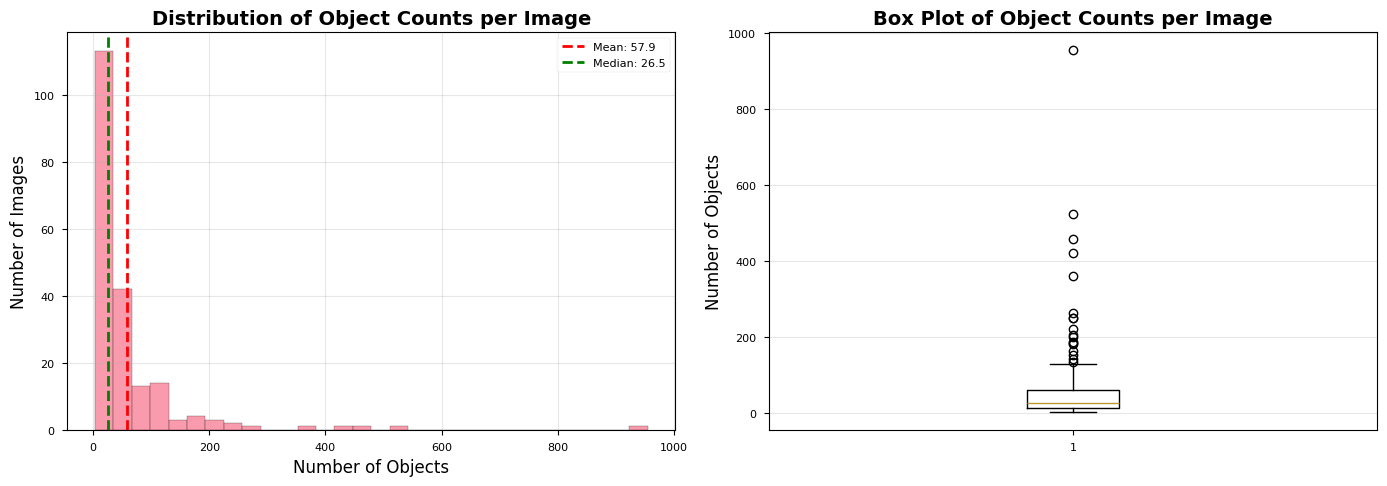

Saved figure: object_distribution.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
counts = list(gt_counts.values())
axes[0].hist(counts, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(avg_count_per_image, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_count_per_image:.1f}')
axes[0].axvline(np.median(counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(counts):.1f}')
axes[0].set_xlabel('Number of Objects', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Distribution of Object Counts per Image', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(counts, vert=True)
axes[1].set_ylabel('Number of Objects', fontsize=12)
axes[1].set_title('Box Plot of Object Counts per Image', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('object_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: object_distribution.png")

## Visualization: Distribution of Classes per Image

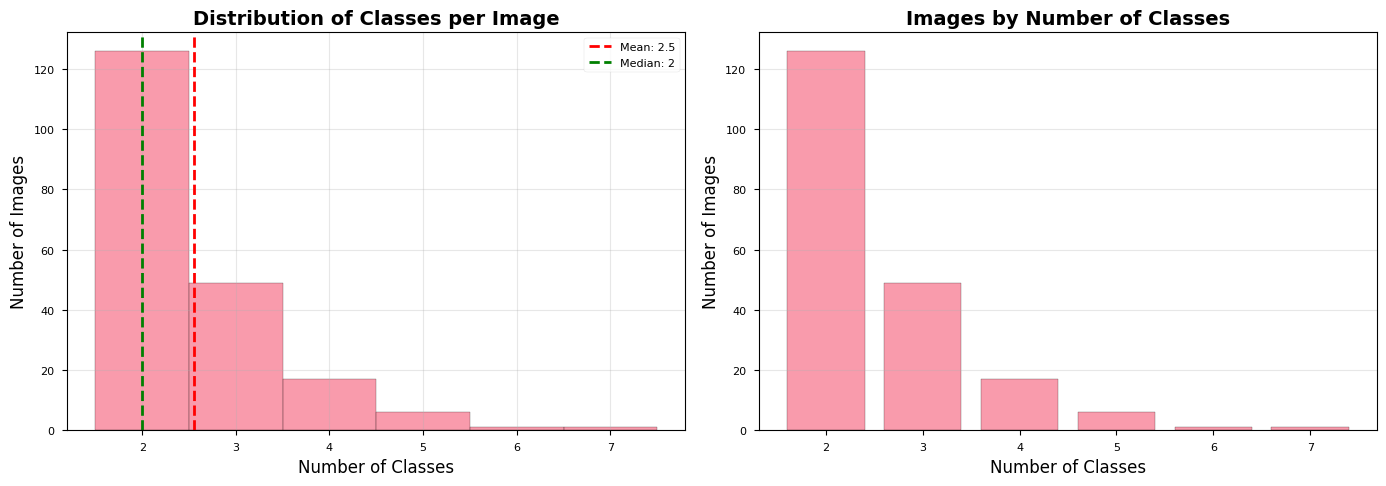

Saved figure: classes_per_image_distribution.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(classes_per_image, bins=range(min_classes, max_classes+2), edgecolor='black', alpha=0.7, align='left')
axes[0].axvline(avg_classes_per_image, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_classes_per_image:.1f}')
axes[0].axvline(median_classes_per_image, color='green', linestyle='--', linewidth=2, label=f'Median: {median_classes_per_image:.0f}')
axes[0].set_xlabel('Number of Classes', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Distribution of Classes per Image', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(min_classes, max_classes+1))

# Bar chart
classes_dist = sorted(classes_distribution.items())
x_vals = [x[0] for x in classes_dist]
y_vals = [x[1] for x in classes_dist]
axes[1].bar(x_vals, y_vals, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Classes', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Images by Number of Classes', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(x_vals)

plt.tight_layout()
plt.savefig('classes_per_image_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: classes_per_image_distribution.png")

## Visualization: Top Classes by Instance Count

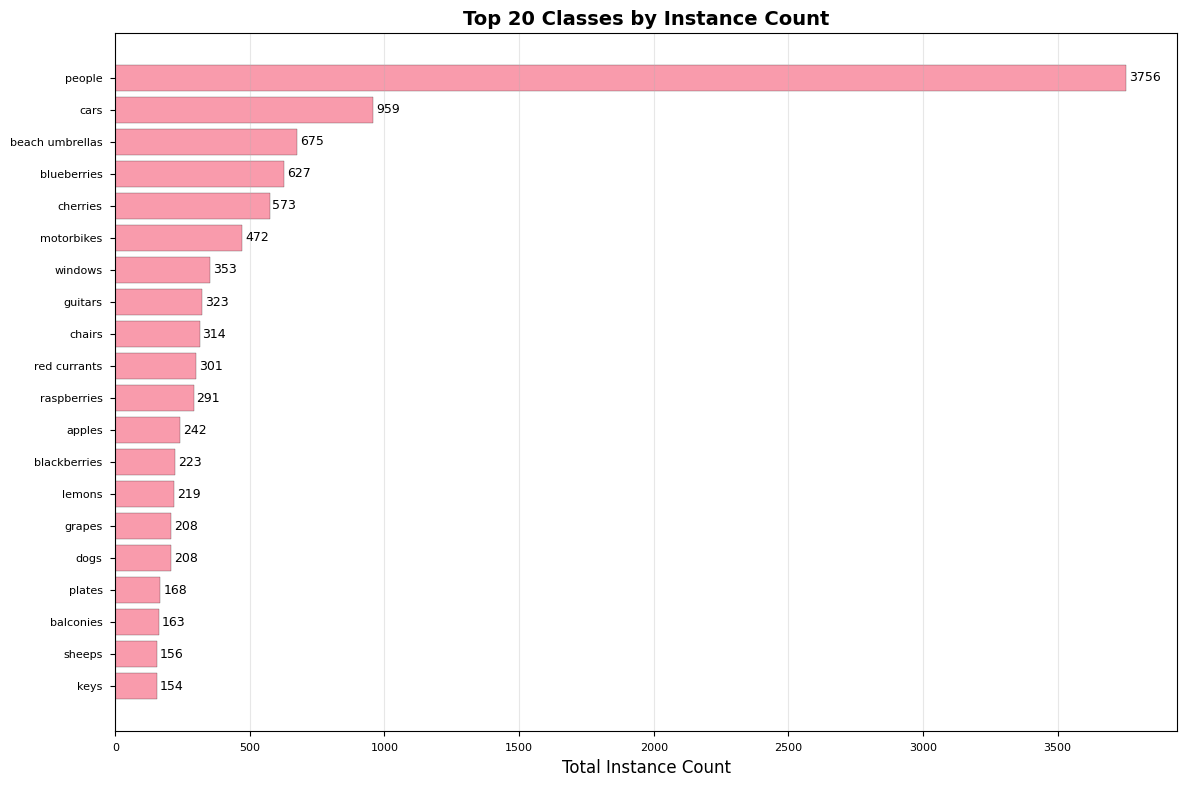

Saved figure: top_classes_by_instances.png


In [29]:
# Top 20 classes by total instances
top_n = 20
df_top = df_class_stats.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_top)), df_top['Total Instances'], edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(df_top)))
ax.set_yticklabels(df_top['Class'])
ax.set_xlabel('Total Instance Count', fontsize=12)
ax.set_title(f'Top {top_n} Classes by Instance Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, row) in enumerate(df_top.iterrows()):
    ax.text(row['Total Instances'] + 10, i, f"{int(row['Total Instances'])}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_classes_by_instances.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: top_classes_by_instances.png")

## Visualization: Classes by Image Frequency

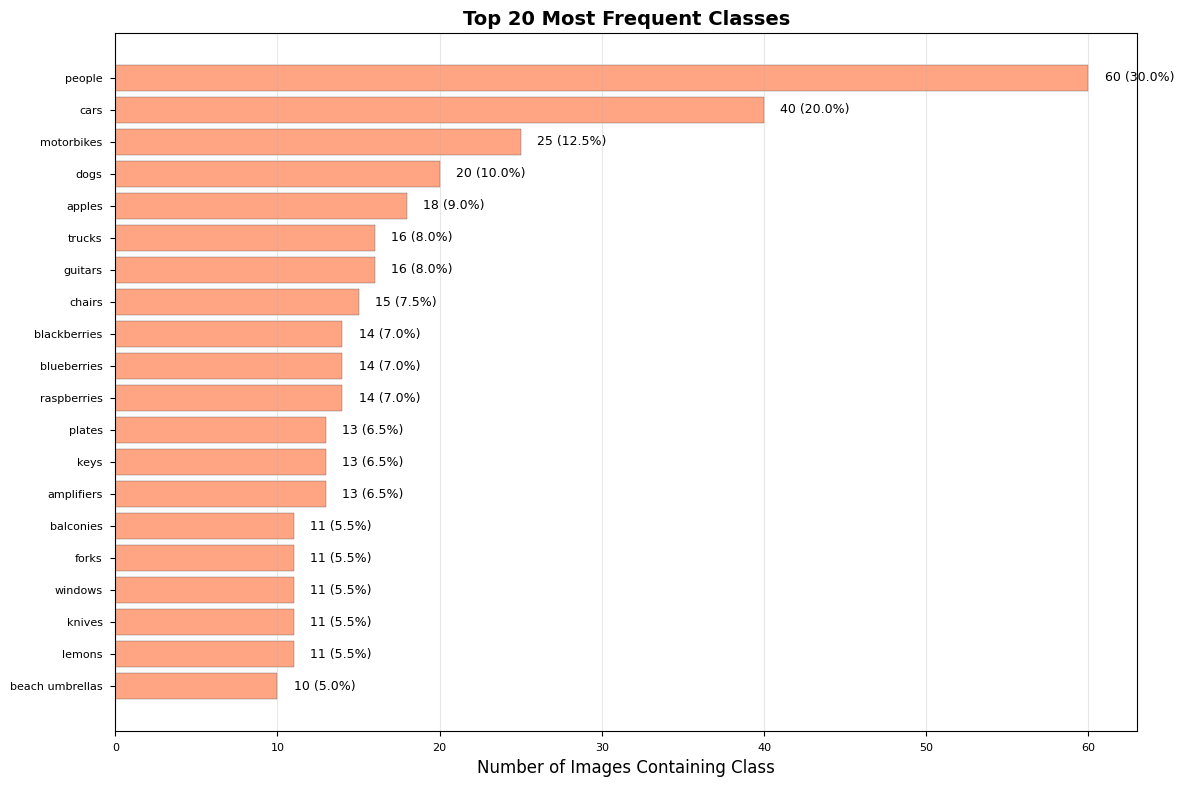

Saved figure: top_classes_by_frequency.png


In [30]:
# Sort by number of images containing each class
df_by_images = df_class_stats.sort_values('Num Images', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_by_images)), df_by_images['Num Images'], edgecolor='black', alpha=0.7, color='coral')
ax.set_yticks(range(len(df_by_images)))
ax.set_yticklabels(df_by_images['Class'])
ax.set_xlabel('Number of Images Containing Class', fontsize=12)
ax.set_title(f'Top {top_n} Most Frequent Classes', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels and percentages
for i, (idx, row) in enumerate(df_by_images.iterrows()):
    percentage = (row['Num Images'] / total_images) * 100
    ax.text(row['Num Images'] + 1, i, f"{int(row['Num Images'])} ({percentage:.1f}%)", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_classes_by_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: top_classes_by_frequency.png")

## Visualization: Average Count per Class (when present)

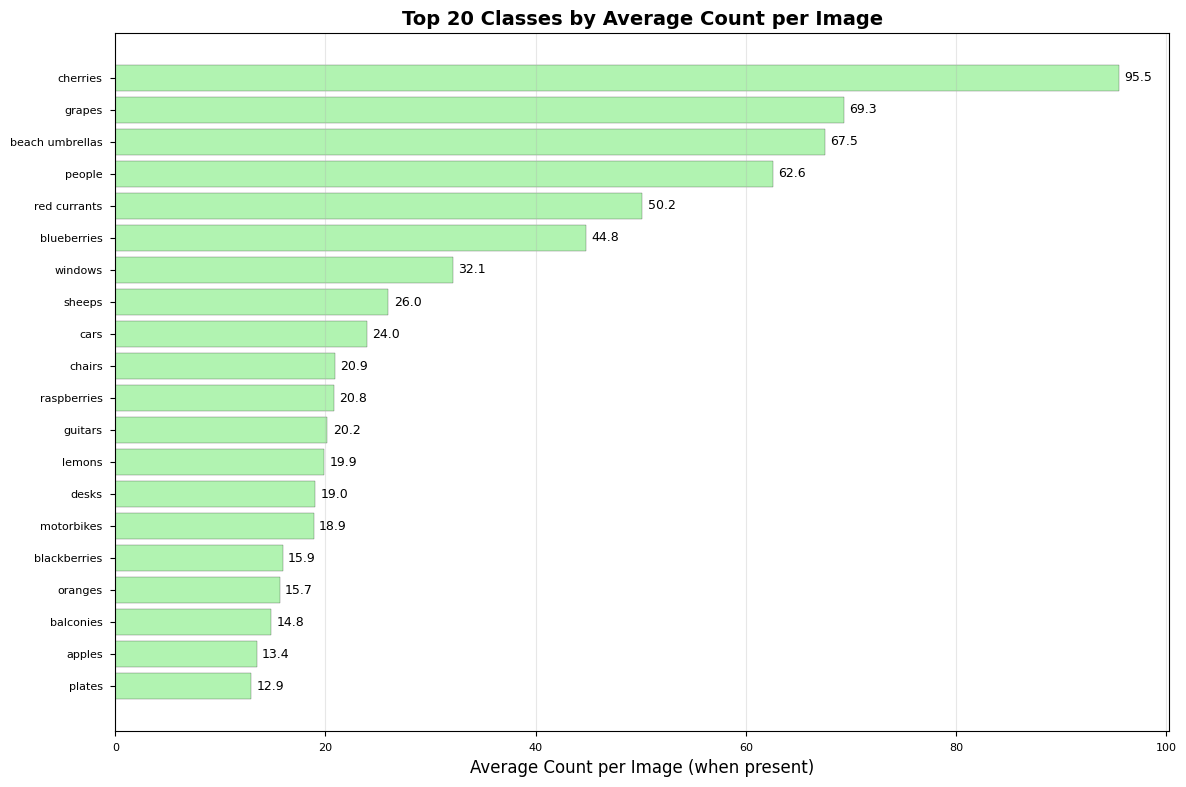

Saved figure: top_classes_by_avg_count.png


In [31]:
# Classes with highest average count when present
df_by_avg = df_class_stats[df_class_stats['Num Images'] > 0].sort_values('Avg per Image', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_by_avg)), df_by_avg['Avg per Image'], edgecolor='black', alpha=0.7, color='lightgreen')
ax.set_yticks(range(len(df_by_avg)))
ax.set_yticklabels(df_by_avg['Class'])
ax.set_xlabel('Average Count per Image (when present)', fontsize=12)
ax.set_title(f'Top {top_n} Classes by Average Count per Image', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(df_by_avg.iterrows()):
    ax.text(row['Avg per Image'] + 0.5, i, f"{row['Avg per Image']:.1f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_classes_by_avg_count.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: top_classes_by_avg_count.png")

## Summary Statistics Table for Paper

In [32]:
# Create a comprehensive summary table
summary_data = {
    'Metric': [
        'Total Images',
        'Total Classes',
        'Total Object Instances',
        'Avg Objects per Image',
        'Median Objects per Image',
        'Min Objects per Image',
        'Max Objects per Image',
        'Avg Classes per Image',
        'Median Classes per Image',
        'Min Classes per Image',
        'Max Classes per Image',
        'Avg Instances per Class',
    ],
    'Value': [
        total_images,
        total_classes,
        f"{total_objects:,}",
        f"{avg_count_per_image:.2f}",
        f"{np.median(list(gt_counts.values())):.0f}",
        min(gt_counts.values()),
        max(gt_counts.values()),
        f"{avg_classes_per_image:.2f}",
        f"{median_classes_per_image:.0f}",
        min_classes,
        max_classes,
        f"{avg_instances_per_class:.2f}",
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY STATISTICS TABLE FOR PAPER")
print("="*60)
print(df_summary.to_string(index=False))
print("="*60)

# Save to CSV
df_summary.to_csv('dataset_summary_statistics.csv', index=False)
print("\nSaved: dataset_summary_statistics.csv")

# Save detailed class statistics
df_class_stats.to_csv('class_statistics.csv', index=False)
print("Saved: class_statistics.csv")


SUMMARY STATISTICS TABLE FOR PAPER
                  Metric  Value
            Total Images    200
           Total Classes     45
  Total Object Instances 11,576
   Avg Objects per Image  57.88
Median Objects per Image     26
   Min Objects per Image      3
   Max Objects per Image    955
   Avg Classes per Image   2.55
Median Classes per Image      2
   Min Classes per Image      2
   Max Classes per Image      7
 Avg Instances per Class 257.24

Saved: dataset_summary_statistics.csv
Saved: class_statistics.csv


## Class Distribution Across Difficulty Levels


Image Distribution by Difficulty:
  Easy (0-20 objects): 87 images (43.5%)
  Medium (21-50 objects): 57 images (28.5%)
  Hard (51-100 objects): 24 images (12.0%)
  Very Hard (>100 objects): 32 images (16.0%)


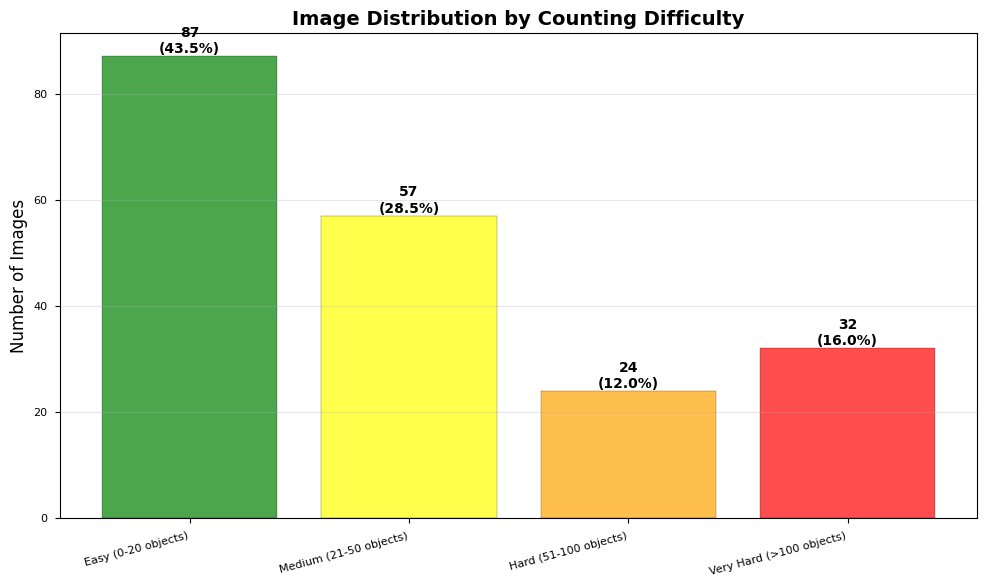

Saved figure: difficulty_distribution.png


In [33]:
# Categorize images by difficulty based on object count
difficulty_bins = [(0, 20, 'Easy (0-20 objects)'), 
                   (21, 50, 'Medium (21-50 objects)'), 
                   (51, 100, 'Hard (51-100 objects)'),
                   (101, float('inf'), 'Very Hard (>100 objects)')]

difficulty_counts = {label: 0 for _, _, label in difficulty_bins}

for img_name, count in gt_counts.items():
    for min_val, max_val, label in difficulty_bins:
        if min_val <= count <= max_val:
            difficulty_counts[label] += 1
            break

print("\nImage Distribution by Difficulty:")
for label, count in difficulty_counts.items():
    percentage = (count / total_images) * 100
    print(f"  {label}: {count} images ({percentage:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(difficulty_counts.keys())
values = list(difficulty_counts.values())
bars = ax.bar(labels, values, edgecolor='black', alpha=0.7, color=['green', 'yellow', 'orange', 'red'])

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution by Counting Difficulty', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/total_images*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('difficulty_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: difficulty_distribution.png")

## Additional Statistics: Image Resolution Analysis


Image Resolution Statistics:
  Width  - Mean: 1021, Min: 225, Max: 4000
  Height - Mean: 774, Min: 181, Max: 4000
  Aspect Ratio - Mean: 1.39, Min: 0.57, Max: 2.70


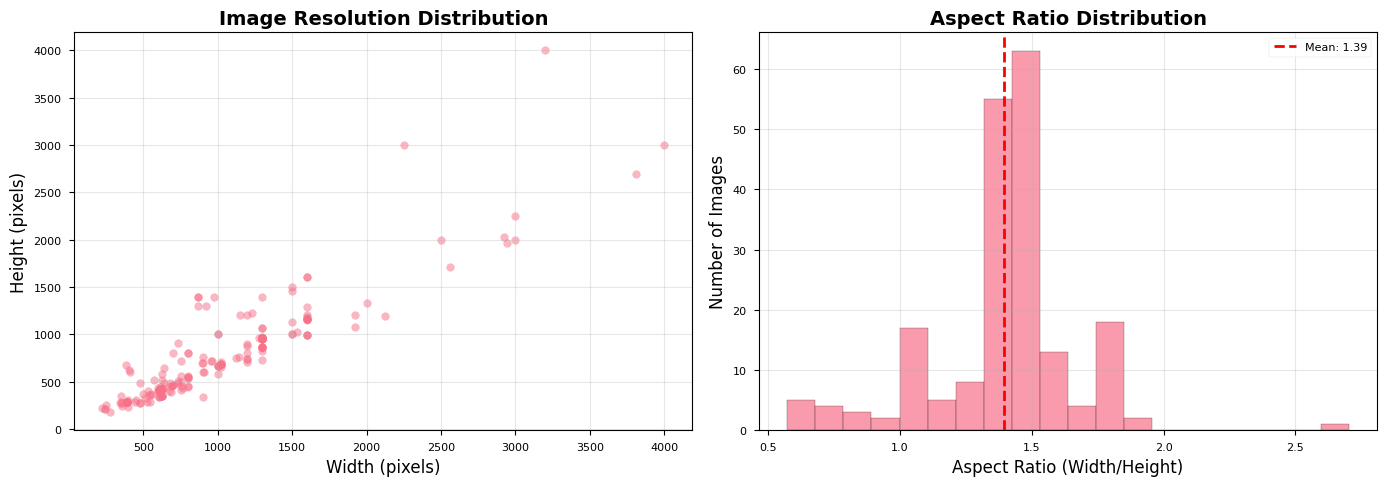

Saved figure: resolution_analysis.png


In [34]:
# Analyze image resolutions
resolutions = []
aspect_ratios = []

for img_name, annotation in annotations.items():
    if 'H' in annotation and 'W' in annotation:
        height = annotation['H']
        width = annotation['W']
        resolutions.append((width, height))
        aspect_ratios.append(width / height)

if resolutions:
    widths = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]
    
    print("\nImage Resolution Statistics:")
    print(f"  Width  - Mean: {np.mean(widths):.0f}, Min: {min(widths)}, Max: {max(widths)}")
    print(f"  Height - Mean: {np.mean(heights):.0f}, Min: {min(heights)}, Max: {max(heights)}")
    print(f"  Aspect Ratio - Mean: {np.mean(aspect_ratios):.2f}, Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot of resolutions
    axes[0].scatter(widths, heights, alpha=0.5)
    axes[0].set_xlabel('Width (pixels)', fontsize=12)
    axes[0].set_ylabel('Height (pixels)', fontsize=12)
    axes[0].set_title('Image Resolution Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Aspect ratio histogram
    axes[1].hist(aspect_ratios, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(aspect_ratios), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(aspect_ratios):.2f}')
    axes[1].set_xlabel('Aspect Ratio (Width/Height)', fontsize=12)
    axes[1].set_ylabel('Number of Images', fontsize=12)
    axes[1].set_title('Aspect Ratio Distribution', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('resolution_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved figure: resolution_analysis.png")

## Export LaTeX Table for Paper

In [35]:
# Create a LaTeX-formatted table
latex_table = r"""
\begin{table}[h]
\centering
\caption{Multiclass Counting Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lr}
\toprule
\textbf{Metric} & \textbf{Value} \\
\midrule
"""

for _, row in df_summary.iterrows():
    latex_table += f"{row['Metric']} & {row['Value']} \\\\ \
        "

latex_table += r"""
\bottomrule
\end{tabular}
\end{table}
"""

with open('dataset_statistics_latex.tex', 'w') as f:
    f.write(latex_table)

print("\nLaTeX table saved to: dataset_statistics_latex.tex")
print("\nLaTeX Table Preview:")
print(latex_table)


LaTeX table saved to: dataset_statistics_latex.tex

LaTeX Table Preview:

\begin{table}[h]
\centering
\caption{Multiclass Counting Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lr}
\toprule
\textbf{Metric} & \textbf{Value} \\
\midrule
Total Images & 200 \\         Total Classes & 45 \\         Total Object Instances & 11,576 \\         Avg Objects per Image & 57.88 \\         Median Objects per Image & 26 \\         Min Objects per Image & 3 \\         Max Objects per Image & 955 \\         Avg Classes per Image & 2.55 \\         Median Classes per Image & 2 \\         Min Classes per Image & 2 \\         Max Classes per Image & 7 \\         Avg Instances per Class & 257.24 \\         
\bottomrule
\end{tabular}
\end{table}



## Final Summary

All statistics have been computed and visualizations generated. The following files have been created:

### CSV Files:
- `dataset_summary_statistics.csv` - Overall dataset statistics
- `class_statistics.csv` - Detailed per-class statistics

### Figures:
- `object_distribution.png` - Distribution of objects per image
- `classes_per_image_distribution.png` - Distribution of classes per image
- `top_classes_by_instances.png` - Top classes by total instances
- `top_classes_by_frequency.png` - Most frequent classes across images
- `top_classes_by_avg_count.png` - Classes with highest average count
- `difficulty_distribution.png` - Images by counting difficulty
- `resolution_analysis.png` - Image resolution and aspect ratio analysis

### LaTeX:
- `dataset_statistics_latex.tex` - LaTeX table for paper inclusion

These comprehensive statistics and visualizations are ready for use in your benchmark paper!